In [1]:
import pandas as pd
import math as mt
import numpy.ma as ma
import numpy as np
from pandas import DataFrame
import matplotlib.pyplot as plt
import scipy as sc
import scipy.stats as sc
from scipy.stats import ttest_ind
import statsmodels
import statsmodels.stats.multitest as multi
import csv
import pathlib
from pathlib import Path

# Variables for input

In [2]:
#directory names
inputfile = (r'path_to_input_folder')
outputfile = pathlib.Path(r'path_to_output_folder')

#file names
mutational_status = 'CCLE_mutations.csv'
drugnames_ = 'primary-screen-replicate-collapsed-treatment-info'
insilicodrugscreen_drugresponse = 'primary-screen-replicate-collapsed-logfold-change'
expression = 'CCLE_expression'
original_cell_names = 'sample_info'

#suffix names
pdf = '.pdf'
csv = '.csv'
html = '.html'

In [3]:
df = pd.read_csv(r'C:\Users\fanis\Desktop\for paper\code\primary-screen-replicate-collapsed-logfold-change.csv')

In [4]:
insilicodrugscreen_drugresponse_input = Path(inputfile, insilicodrugscreen_drugresponse).with_suffix(csv)
df = pd.read_csv(insilicodrugscreen_drugresponse_input)#.fillna(0) - removed skipna and omit na in mean and ttest values respectively.

In [5]:
df.shape

(578, 4687)

In [6]:
# Database for genetic mutations per cell line
mutational_status_input = Path(inputfile, mutational_status).with_suffix(csv)
df1 = pd.read_csv(mutational_status_input, low_memory=False)

In [7]:
# Database for drug name class, MOA, drug class
drugname_input = Path(inputfile, drugnames_).with_suffix(csv)
drugnames = pd.read_csv(drugname_input)

In [8]:
# cell names if you need
original_cell_names_input = Path(inputfile, original_cell_names).with_suffix(csv)
origina_cell_names = pd.read_csv(original_cell_names_input)

# Search criteria - specify mutation

In [9]:
#set DepMap_ID as index and drop uneeded columns for future merge steps
df2 = df1.drop(columns=['Tumor_Seq_Allele1','dbSNP_RS','Codon_Change','dbSNP_Val_Status','Genome_Change', 'isDeleterious', 'Annotation_Transcript','cDNA_Change', 'isTCGAhotspot', 'TCGAhsCnt','Entrez_Gene_Id','NCBI_Build', 'Chromosome', 'Start_position', 'End_position', 'Strand', 'Variant_Type', 'Reference_Allele','isCOSMIChotspot', 'COSMIChsCnt', 'ExAC_AF', 'Variant_annotation', 'CGA_WES_AC', 'HC_AC', 'RD_AC', 'RNAseq_AC', 'SangerWES_AC', 'WGS_AC'])
df2 = df2.set_index('DepMap_ID')

In [10]:
#this is to search strings which contain...
#In other words here the exact name of gene has to be specified
searchfor = 'KRAS'
gene_only = df2[df2['Hugo_Symbol'] == searchfor] 

In [11]:
#Here specify the exact variants of the above mentioned gene
searchfor2 = ['G12','Q61']

# Filter gene_only dataframe where Protein_Change contains G12 or Q61, and Variant_Classification is 'Missense_Mutation'
gene_only2 = gene_only.loc[
    gene_only['Protein_Change'].str.contains('|'.join(searchfor2), na=False) & 
    (gene_only['Variant_Classification'] == 'Missense_Mutation')]


# Removing cell lines which are in DEPMAP drug sensitivity database but not in the CCLE_mutation file

In [12]:
# Make dataframe containing all cell lines which are included in the CCLE_mutation file
df2_2 = df2[~df2.index.duplicated(keep='first')]

In [13]:
# set DepMap_ID ID as index and rename to DepMap ID
df_1 = df.set_index('Unnamed: 0')
df_1 = df_1.rename_axis('DepMap_ID')

In [14]:
# Remove all cell lines in DEPMAP drug sensitivity for which mutational status is not known
df_1 = df_1[df_1.index.isin(df2_2.index)]

In [15]:
#Number of cells with known mutational status
print("Number of cell lines with known mutational status:", df_1.shape[0])

Number of cell lines with known mutational status: 564


# Fuse DepMap drug sensnitvity data with CCLE mutational staus

In [16]:
# Fusing mutant cell lines with drug response, mutant is non specified variant, and precise_mutant is for specified variants

# Here mutant is all mutants
prefinalmutant = pd.merge(gene_only, df_1, left_index=True, right_index=True)

# Here precise_mutant is mutants with specified variants
prefinal_precise_mutant = pd.merge(gene_only2, df_1, left_index=True, right_index=True)

In [17]:
# Here I am removing cell lines that come up twice in the mutants because they have more than one mutation in the same gene
mutant = prefinalmutant[~prefinalmutant.index.duplicated(keep='first')]
precise_mutant = prefinal_precise_mutant[~prefinal_precise_mutant.index.duplicated(keep='first')]

In [18]:
#Number of cells with known mutational status
print("Total number of mutant cells:", mutant.shape[0])

Total number of mutant cells: 122


In [19]:
#Number of cells containing varinat of interest
print("Number of mutant cells with variant of interest:", precise_mutant.shape[0])

Number of mutant cells with variant of interest: 103


# Remove the mutant cells from the list of cells used in drug screen to get WT cohort

In [20]:
#Remove all mutant cell lines from DepMap drug sensitivy dataframe to leave cell lines which do not contain mutation in gene of interest - these are the WT cells
WT = df_1[~df_1.index.isin(mutant.index)]

In [21]:
#Number of WT cells
print("Number of WT cells:", WT.shape[0])

Number of WT cells: 442


# Calculating Mean response of mutants vs WT for each drugs and significance testing

In [22]:
#Calculating mean MFI value of each drug tested on WT cells
ls_WT_mean = WT.iloc[:,:].mean(skipna=True)
df_WT_mean = pd.DataFrame(ls_WT_mean)
df_WT_mean.columns = ['WT_mean_value']

In [23]:
#Calculating mean MFI value of each drug tested on mutant cells
ls_mut_mean = precise_mutant.iloc[:,3:].mean(skipna=True)
df_mut_mean = pd.DataFrame(ls_mut_mean)
df_mut_mean.columns = ['mut_mean_value']

In [24]:
idx = 1
mut_col = df_mut_mean['mut_mean_value']  # can be a list, a Series, an array or a scalar   
df_WT_mean.insert(loc=idx, column='mut_mean_value', value=mut_col)

In [25]:
df_WT_mean['drug name'] = df_WT_mean.index

In [26]:
# Perform Ttests between Wt and mutants for each drug

common_cols = WT.columns.intersection(precise_mutant.columns[3:])


# Dictionary to store results
results = []

# Perform t-test only on matched column names
for col in common_cols:
    t_stat, p_value = ttest_ind(WT[col], precise_mutant[col], nan_policy='omit')
    results.append({'index': col, 'tstatistic': t_stat, 'pvalue': p_value})

# Convert results into a DataFrame with 'Column' as index
t_test_results_df = pd.DataFrame(results).set_index('index')
t_test_results_df.head()

,tstatistic,pvalue
index,,
BRD-A00077618-236-07-6::2.5::HTS,-0.611596,0.541065
BRD-A00100033-001-08-9::2.5::HTS,0.181161,0.856309
BRD-A00147595-001-01-5::2.5::HTS,0.757146,0.449296
BRD-A00218260-001-03-4::2.5::HTS,0.393632,0.694010
BRD-A00376169-001-01-6::2.5::HTS,0.460392,0.645423


In [27]:
# merge mutant and WT means + TTEST results

final_unfiltered = pd.merge(df_WT_mean, t_test_results_df, left_index=True, right_index=True)
final_unfiltered.head(3)

,WT_mean_value,mut_mean_value,drug name,tstatistic,pvalue
BRD-A00077618-236-07-6::2.5::HTS,-0.008945,0.022087,BRD-A00077618-236-07-6::2.5::HTS,-0.611596,0.541065
BRD-A00100033-001-08-9::2.5::HTS,-0.208435,-0.216394,BRD-A00100033-001-08-9::2.5::HTS,0.181161,0.856309
BRD-A00147595-001-01-5::2.5::HTS,0.063151,0.027927,BRD-A00147595-001-01-5::2.5::HTS,0.757146,0.449296


In [28]:
 #Slice out the extra string sequence containing ScreenID and not information of BROAD compound naming

final_unfiltered = final_unfiltered.reset_index()
final_unfiltered["drug name"]= final_unfiltered["drug name"].str.slice(stop=22)
final_unfiltered_drugindex = final_unfiltered.set_index('drug name')
drugnames_drugindex = drugnames.set_index('broad_id')
drugnames_drugindex.head(3)

,column_name,name,dose,screen_id,moa,target,disease.area,indication,smiles,phase
broad_id,,,,,,,,,,
BRD-A00055058-001-01-0,BRD-A00055058-001-01-0::2.325889319::MTS004,RS-0481,2.325889,MTS004,immunostimulant,NaN,NaN,NaN,CC(NC(=O)C1CSCN1C(=O)c1ccccc1)c1ccccc1,Phase 2
BRD-A00842753-001-01-9,BRD-A00842753-001-01-9::2.5::MTS004,oleuropein,2.500000,MTS004,estrogen receptor agonist,GPER1,NaN,NaN,COC(=O)C1=COC(OC2OC(CO)C(O)C(O)C2O)\C(=C/C)C1C...,Phase 2
BRD-A02232681-001-01-8,BRD-A02232681-001-01-8::2.5::MTS004,isoleucine,2.500000,MTS004,NaN,"ACADSB, BCAT1, BCAT2, IARS, IARS2",NaN,NaN,CCC(C)C(N)C(O)=O,Launched


In [29]:
#Merge in the common names of compounds 
intermediate_completeDF = pd.merge(drugnames_drugindex, final_unfiltered_drugindex, left_index=True, right_index=True)
intermediate_completeDF1 = intermediate_completeDF.reset_index()
intermediate_completeDF2 = intermediate_completeDF1.set_index('name')
intermediate_completeDF3 = intermediate_completeDF2.drop(columns=['column_name', 'dose', 'screen_id','target','disease.area','indication','smiles','phase'])


In [30]:
#Calculating difference between Log2 survival values in mutants vs WT 
intermediate_completeDF3['difference'] =  intermediate_completeDF3['mut_mean_value'] -  intermediate_completeDF3['WT_mean_value']

In [31]:
export_drugname = intermediate_completeDF['name']
export_drugname2 = export_drugname.reset_index()

In [32]:
export_drugname2.drop(columns=['index'])
#ls_WT_mean = WT.iloc[:,:].mean(skipna=True)
arr = export_drugname2["name"].to_numpy()

# False Discovery Rate

In [33]:
#rename column to pvalue
pv = intermediate_completeDF3['pvalue']

In [38]:
# check here for which tests are available https://www.statsmodels.org/devel/generated/statsmodels.stats.multitest.multipletests.html#statsmodels.stats.multitest.multipletests
qv = statsmodels.stats.multitest.multipletests(pv, alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)
qg = qv[0:2]
#(np.array(qg))
qg = pd.DataFrame(qg) 
qg1 = DataFrame(qg).transpose()
qg1.columns = ['False/True','Adjusted_pvalue']
# try also bonferroni/fdr_bh

# Filtering total Data for drugs which cells containing mutation are sensitive (sensitivity hits) or resistant (resistance hits) to

In [39]:
# merging in the Adjusted T-test results
filtered_completeDF1 = intermediate_completeDF3.reset_index()
filtered_completeDF2 = pd.merge(filtered_completeDF1, qg1, left_index=True, right_index=True)
filtered_completeDF2['Adjusted_pvalue'] = filtered_completeDF2['Adjusted_pvalue'].astype(float)
filtered_completeDF2['Adjusted_pvalue -LOG10'] = np.log10(filtered_completeDF2['Adjusted_pvalue'])*-1
filtered_completeDF3 = filtered_completeDF2.set_index('name')
filtered_completeDF3.head(3)

,level_0,moa,index,WT_mean_value,mut_mean_value,tstatistic,pvalue,difference,False/True,Adjusted_pvalue,Adjusted_pvalue -LOG10
name,,,,,,,,,,,
RS-0481,BRD-A00055058-001-01-0,immunostimulant,BRD-A00055058-001-01-0::2.325889319::MTS004,-0.012904,-0.017629,0.140135,0.888608,-0.004726,False,0.982719,0.007571
oleuropein,BRD-A00842753-001-01-9,estrogen receptor agonist,BRD-A00842753-001-01-9::2.5::MTS004,0.073342,0.090471,-0.502092,0.615816,0.017129,False,0.941813,0.026035
isoleucine,BRD-A02232681-001-01-8,NaN,BRD-A02232681-001-01-8::2.5::MTS004,-0.043211,-0.017079,-0.790548,0.429569,0.026133,False,0.892307,0.049486


#added recently for -log10 correction convert dtype to float
filtered_completeDF2['Adjusted_pvalue'] = filtered_completeDF2['Adjusted_pvalue'].astype(float)

In [40]:
#add Adjusted -log10 Pvalue for easier visualisation
filtered_completeDF2['Adjusted_pvalue-LOG10'] = np.log10(filtered_completeDF2['Adjusted_pvalue'])*-1

## Sensitive

In [41]:
#SENSITIVE filtering drugs which make cells sensitive - values that have larger MFI values for WT than for mutants (which work best for Mutant) and for which q value < 0.05
filtered_completeDF4 = filtered_completeDF3.where(filtered_completeDF3['WT_mean_value'] > filtered_completeDF3['mut_mean_value'])
filtered_completeDF5 = filtered_completeDF4.where(filtered_completeDF4['Adjusted_pvalue']<0.05)
filtered_completeDF6 = filtered_completeDF5[filtered_completeDF5['Adjusted_pvalue'].notna()]
filtered_completeDF7 = filtered_completeDF6.sort_values(by=['difference'], ascending= True)

In [42]:
filtered_completeDF82 = filtered_completeDF7.drop(columns=['pvalue','index','tstatistic', 'False/True', 'WT_mean_value', 'pvalue', 'mut_mean_value' ])
filtered_completeDF82['drug name'] = filtered_completeDF82.index
filtered_completeDF92= filtered_completeDF82[['drug name','moa','difference', 'Adjusted_pvalue']]
filtered_completeDF92.columns = ['drug name','mechanism of action', 'Log2(MFI) differential', 'Adjusted_pvalue']

In [43]:
# sensitive export all data for most significant hits
outputfile.mkdir(parents=True, exist_ok=True)
complete_data = "drugs_sensitive_hits_KRAS_significant" 

#export to csv format
filtered_completeDF92_csv = Path(outputfile, complete_data).with_suffix(csv)
filtered_completeDF92.to_csv(filtered_completeDF92_csv, index=False)

## Resistant

In [44]:
# RESISTANT filtering drugs which make cells resistant - values that have larger MFI values for WT than for mutants (which work best for Mutant) and for which q value < 0.05
resistant_filtered_completeDF4 = filtered_completeDF3.where(filtered_completeDF3['WT_mean_value'] < filtered_completeDF3['mut_mean_value'])
resistant_filtered_completeDF5 = resistant_filtered_completeDF4.where(resistant_filtered_completeDF4['Adjusted_pvalue']<0.05)
resistant_filtered_completeDF6 = resistant_filtered_completeDF5[resistant_filtered_completeDF5['Adjusted_pvalue'].notna()]
resistant_filtered_completeDF7 = resistant_filtered_completeDF6.sort_values(by=['difference'], ascending= True)

In [45]:
# Resistant Neat table to export which will couple graph
resistant_filtered_completeDF82 = resistant_filtered_completeDF7.drop(columns=['pvalue','index','tstatistic', 'False/True', 'WT_mean_value', 'pvalue', 'mut_mean_value' ])
resistant_filtered_completeDF82['drug name'] = resistant_filtered_completeDF82.index
resistant_filtered_completeDF92= resistant_filtered_completeDF82[['drug name','moa','difference', 'Adjusted_pvalue']]
resistant_filtered_completeDF92.columns = ['drug name','mechanism of action', 'Log2(MFI) differential', 'Adjusted_pvalue']

In [46]:
# Resistant export all data for most significant hits

outputfile.mkdir(parents=True, exist_ok=True)
complete_data = "drugs_resistance_hits_KRAS_significant" 

#export to html format
resistant_filtered_completeDF92_csv = Path(outputfile, complete_data).with_suffix(csv)
resistant_filtered_completeDF92.to_csv(resistant_filtered_completeDF92_csv, index=False)

## volcano plot

In [47]:
# filtering - All data which are not significant 
nonsignfificant_completeDF5 = pd.concat([filtered_completeDF3, filtered_completeDF6]).drop_duplicates(keep=False)

In [48]:
#this is to search strings which contain...
label = filtered_completeDF7[filtered_completeDF82['drug name'] == 'AR-A014418']
label2 = filtered_completeDF7[filtered_completeDF82['drug name'] == 'trametinib']
label = label.reset_index()
label2 = label2.reset_index()

PDF saved at: C:\Users\fanis\Desktop\archive format\letter paper\JID-2025-0146_FM_archive\Figure 1\panels_1A_1B\output\Figure1A_rank_volcano_plot.pdf
TIFF saved at: C:\Users\fanis\Desktop\archive format\letter paper\JID-2025-0146_FM_archive\Figure 1\panels_1A_1B\output\Figure1A_rank_volcano_plot.tiff


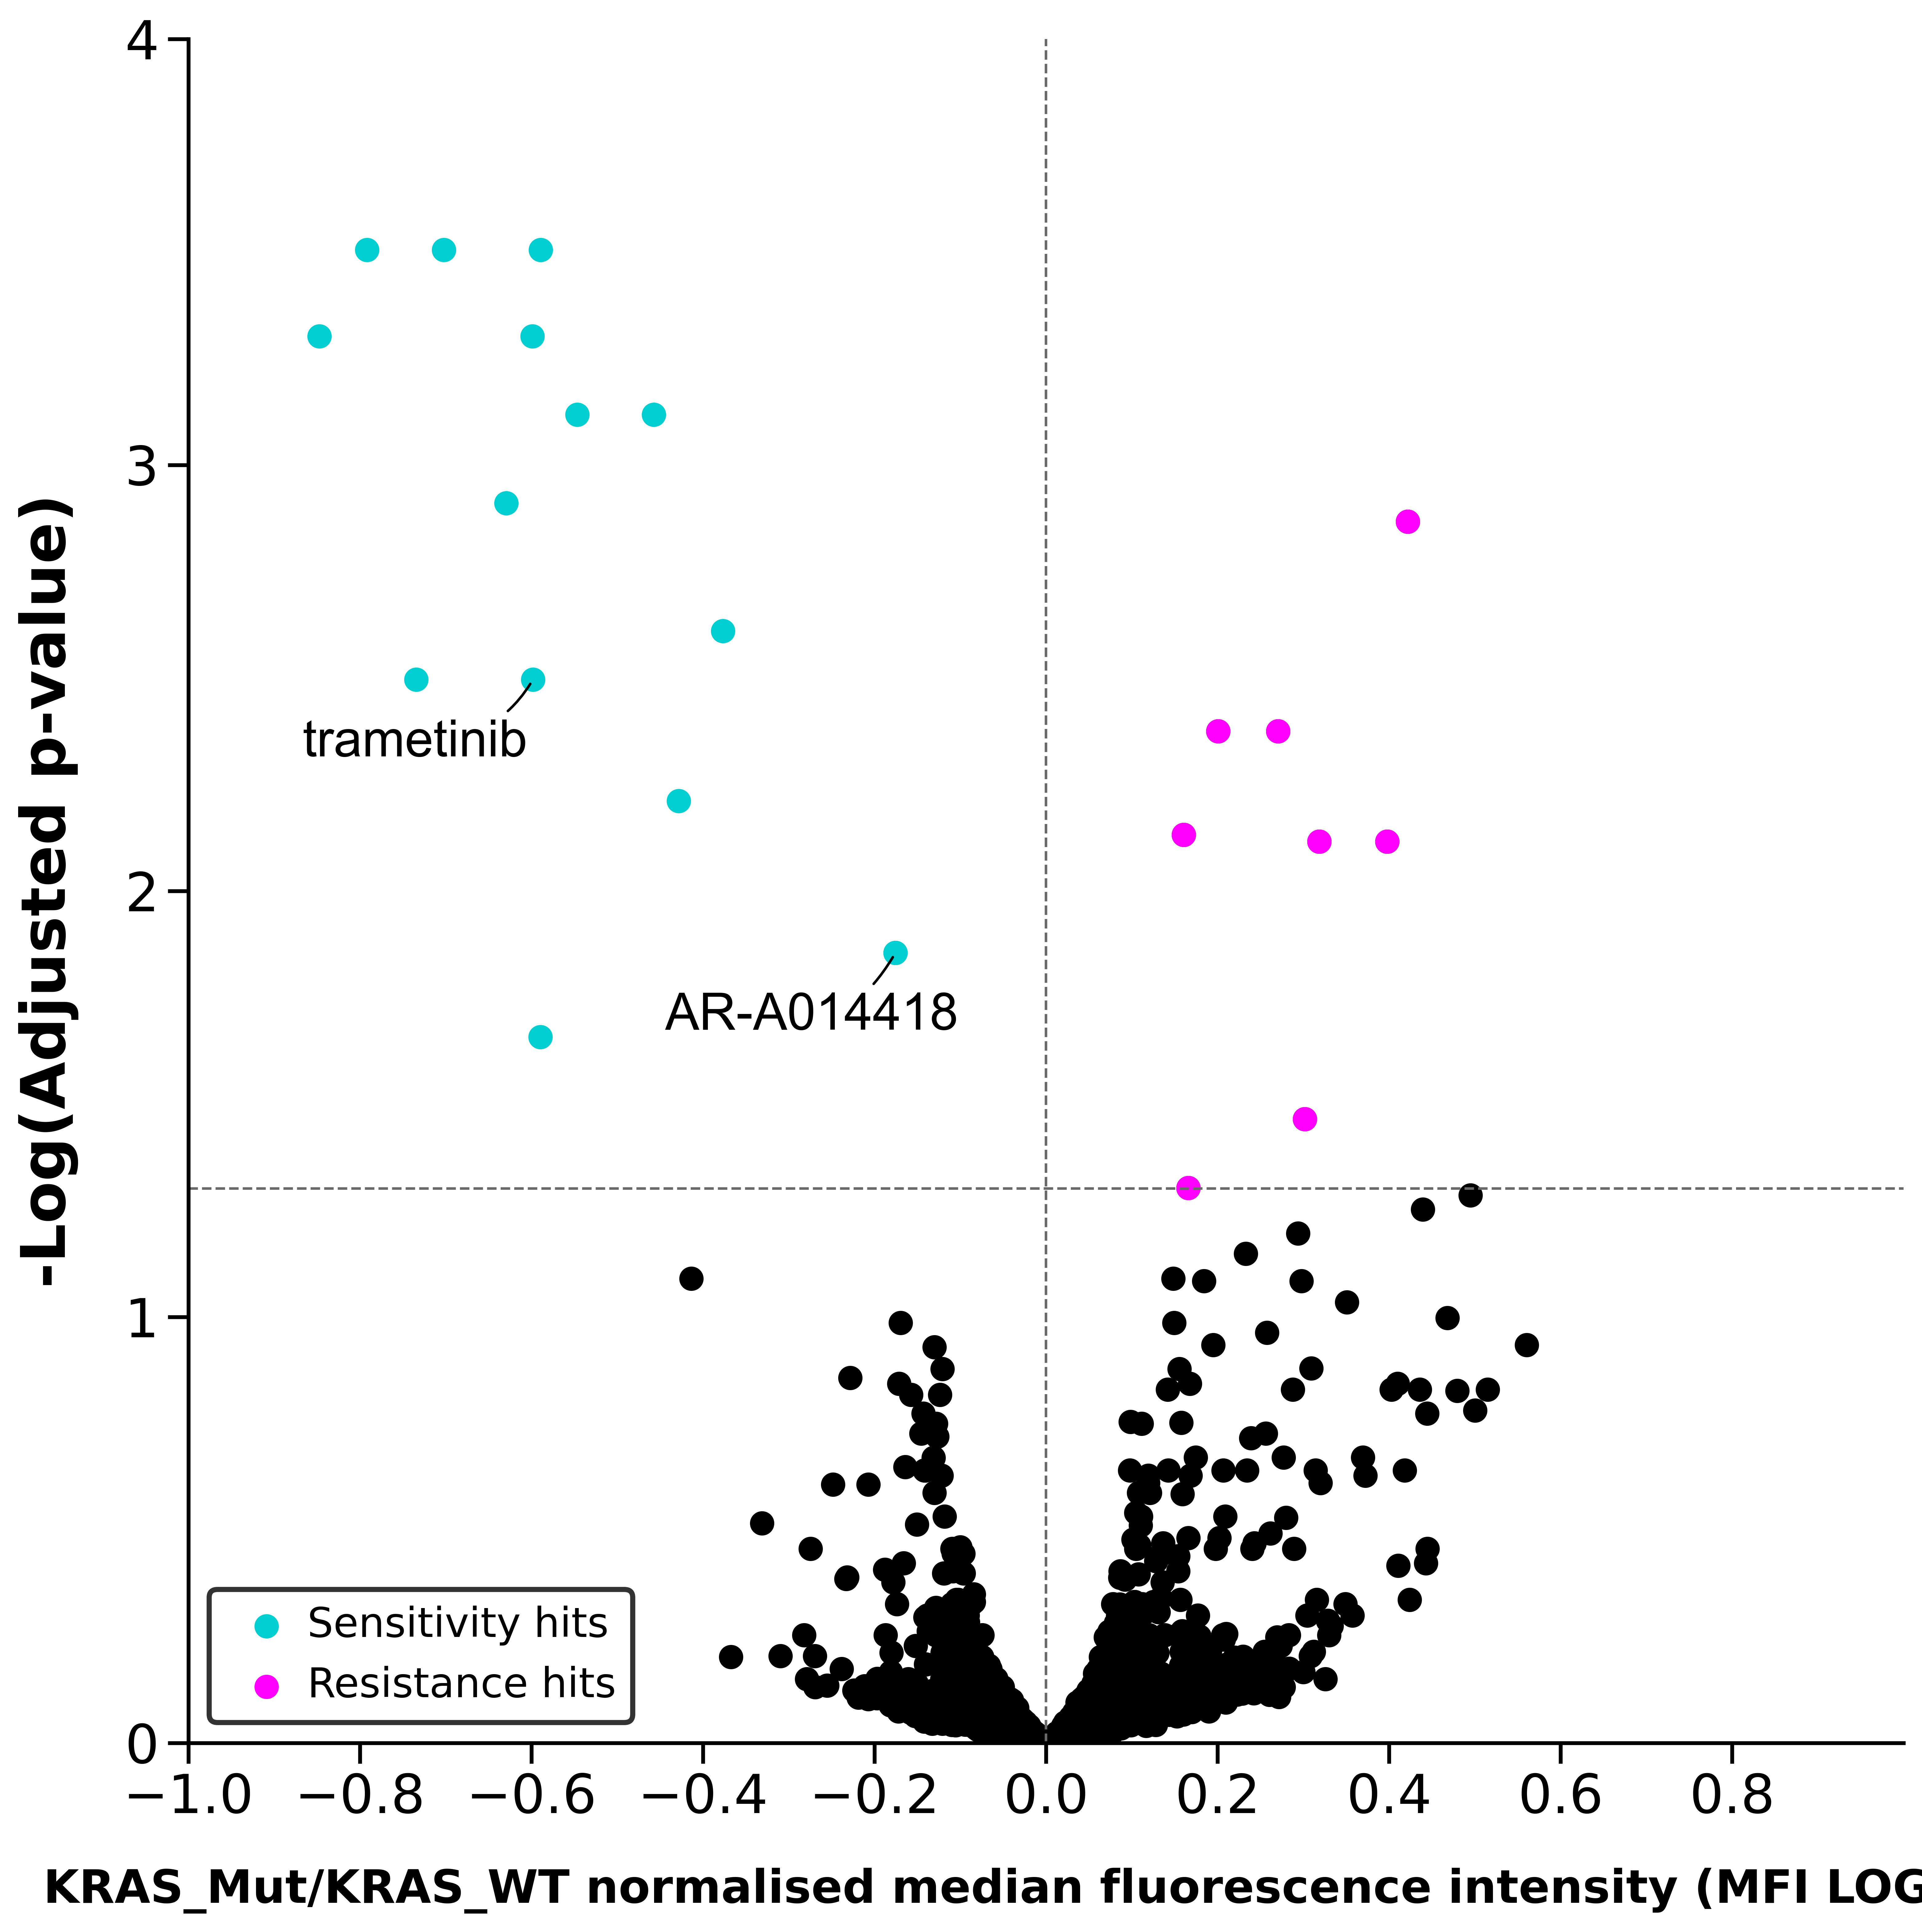

In [49]:
# Specify the output directory
outputfile = pathlib.Path(r"C:\Users\fanis\Desktop\archive format\letter paper\JID-2025-0146_FM_archive\Figure 1\panels_1A_1B\output")

# Ensure the directory exists
outputfile.mkdir(parents=True, exist_ok=True)  # Create the directory if it doesn't exist

# Plotting logic
horizontal_line = np.log10(0.05) * -1
x = filtered_completeDF7['difference']
xr = resistant_filtered_completeDF7['difference']
x1 = nonsignfificant_completeDF5['difference']
y = filtered_completeDF7['Adjusted_pvalue -LOG10']
yr = resistant_filtered_completeDF7['Adjusted_pvalue -LOG10']
y1 = nonsignfificant_completeDF5['Adjusted_pvalue -LOG10']
n1 = nonsignfificant_completeDF5['index']
xg = label['difference']
yg = label['Adjusted_pvalue -LOG10']
ygname = label['name']
xh = label2['difference']
yh = label2['Adjusted_pvalue -LOG10']
yhname = label2['name']

# Creating figure and axis
plt.figure(figsize=(12, 12), dpi=600)
ax = plt.gca()
ax.set_ylim(ax.get_ylim()[::1])
ax.spines['right'].set_visible(False)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
ax.spines['top'].set_visible(False)
plt.rc('axes', labelsize=14)

# Labels and ticks
plt.xlabel('KRAS_Mut/KRAS_WT normalised median fluorescence intensity (MFI LOG2FC)', fontsize=18, labelpad=17, fontweight='bold')
plt.ylabel('-Log(Adjusted p-value)', fontsize=24, labelpad=18, fontweight='bold')
plt.xticks(np.arange(-1, 1, step=0.2), fontsize=21, fontweight='normal')
plt.yticks(np.arange(0.0, 5, step=1), fontsize=21, fontweight='normal')
plt.axhline(horizontal_line, linewidth=1, linestyle='--', color='dimgrey')
plt.axvline(0, linewidth=1, linestyle='--', color='dimgrey')

# Set x-axis range
ax.set_xlim(left=-1, right=1)  # Set x-axis limit to -1 to 1

# Make axes thicker
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Make ticks thicker
ax.tick_params(axis='both', width=1.5, length=8)

hfont = {'fontname': 'arial'}

# Scatter plot
plt.scatter(x1, y1, s=360, marker='.', color='black', linewidth=0, label="")
plt.scatter(x, y, s=360, marker='.', color='darkturquoise', linewidth=0, label='Sensitivity hits')
plt.scatter(xr, yr, s=360, marker='.', color='magenta', linewidth=0.0, label='Resistance hits')
plt.scatter(xg, yg, s=360, marker='.', color='darkturquoise', linewidth=0)

# Annotating points
for i, txt in enumerate(ygname):
    ax.annotate(txt, (xg[i], yg[i]), fontsize=20, xytext=(-90, -30), **hfont, textcoords='offset points', 
                arrowprops=dict(arrowstyle="-", connectionstyle="angle3,angleA=0,angleB=-120"))

for i, txt in enumerate(yhname):
    ax.annotate(txt, (xh[i], yh[i]), fontsize=20, xytext=(-90, -30), **hfont, textcoords='offset points', 
                arrowprops=dict(arrowstyle="-", connectionstyle="angle3,angleA=0,angleB=-120"))

# Legend configuration
legend = plt.legend(loc="lower left", prop={'size': 16}, handletextpad=0)
legend.get_frame().set_linewidth(2)  # Set legend border linewidth
legend.get_frame().set_edgecolor('black')  # Set legend border color

# Export the plot as both PDF and TIFF
rank_volcano_plot_pdf = "Figure1A_rank_volcano_plot.pdf"
rank_volcano_plot_tiff = "Figure1A_rank_volcano_plot.tiff"

# Save as PDF
plotpath_pdf = outputfile / rank_volcano_plot_pdf
plt.savefig(plotpath_pdf, bbox_inches='tight', format='pdf')  # Save as PDF
print(f"PDF saved at: {plotpath_pdf}")  # Optional print for confirmation

# Save as TIFF
plotpath_tiff = outputfile / rank_volcano_plot_tiff
plt.savefig(plotpath_tiff, bbox_inches='tight', format='tiff')  # Save as TIFF
print(f"TIFF saved at: {plotpath_tiff}")  # Optional print for confirmation

# Show the plot (optional)
plt.show()


## PLOT MOA fraction of total sensitivity hit compounds

In [50]:

drug_category_fraction = filtered_completeDF7['moa'].value_counts(normalize=True) * 1
MOA_fraction = filtered_completeDF7['moa'].value_counts(normalize=True) * 100
MOA_fraction = pd.DataFrame(MOA_fraction)
MOA_fraction.columns = ['drug moa of drugs effective in KRAS mutant']

# Modify row names to go over two lines
MOA_fraction.index = [name.replace(", ", "\n") for name in MOA_fraction.index]

MOA_fraction.index = [index.replace("glycogen synthase kinase inhibitor", "glycogen synthase\n kinase inhibitor") if index == "glycogen synthase kinase inhibitor" else index for index in MOA_fraction.index]


# Now your row names will have two lines in the table
print(MOA_fraction)

MOA_fraction.head(5)

                                      drug moa of drugs effective in KRAS mutant
MEK inhibitor                                                          85.714286
MAP kinase inhibitor\nMEK inhibitor                                     7.142857
glycogen synthase\n kinase inhibitor                                    7.142857


,drug moa of drugs effective in KRAS mutant
MEK inhibitor,85.714286
MAP kinase inhibitor\nMEK inhibitor,7.142857
glycogen synthase\n kinase inhibitor,7.142857


PDF saved at: C:\Users\fanis\Desktop\archive format\letter paper\JID-2025-0146_FM_archive\Figure 1\panels_1A_1B\output\Figure1B_KRAS_sensitivity_category_bargraph.pdf
TIFF saved at: C:\Users\fanis\Desktop\archive format\letter paper\JID-2025-0146_FM_archive\Figure 1\panels_1A_1B\output\Figure1B_KRAS_sensitivity_category_bargraph.tiff


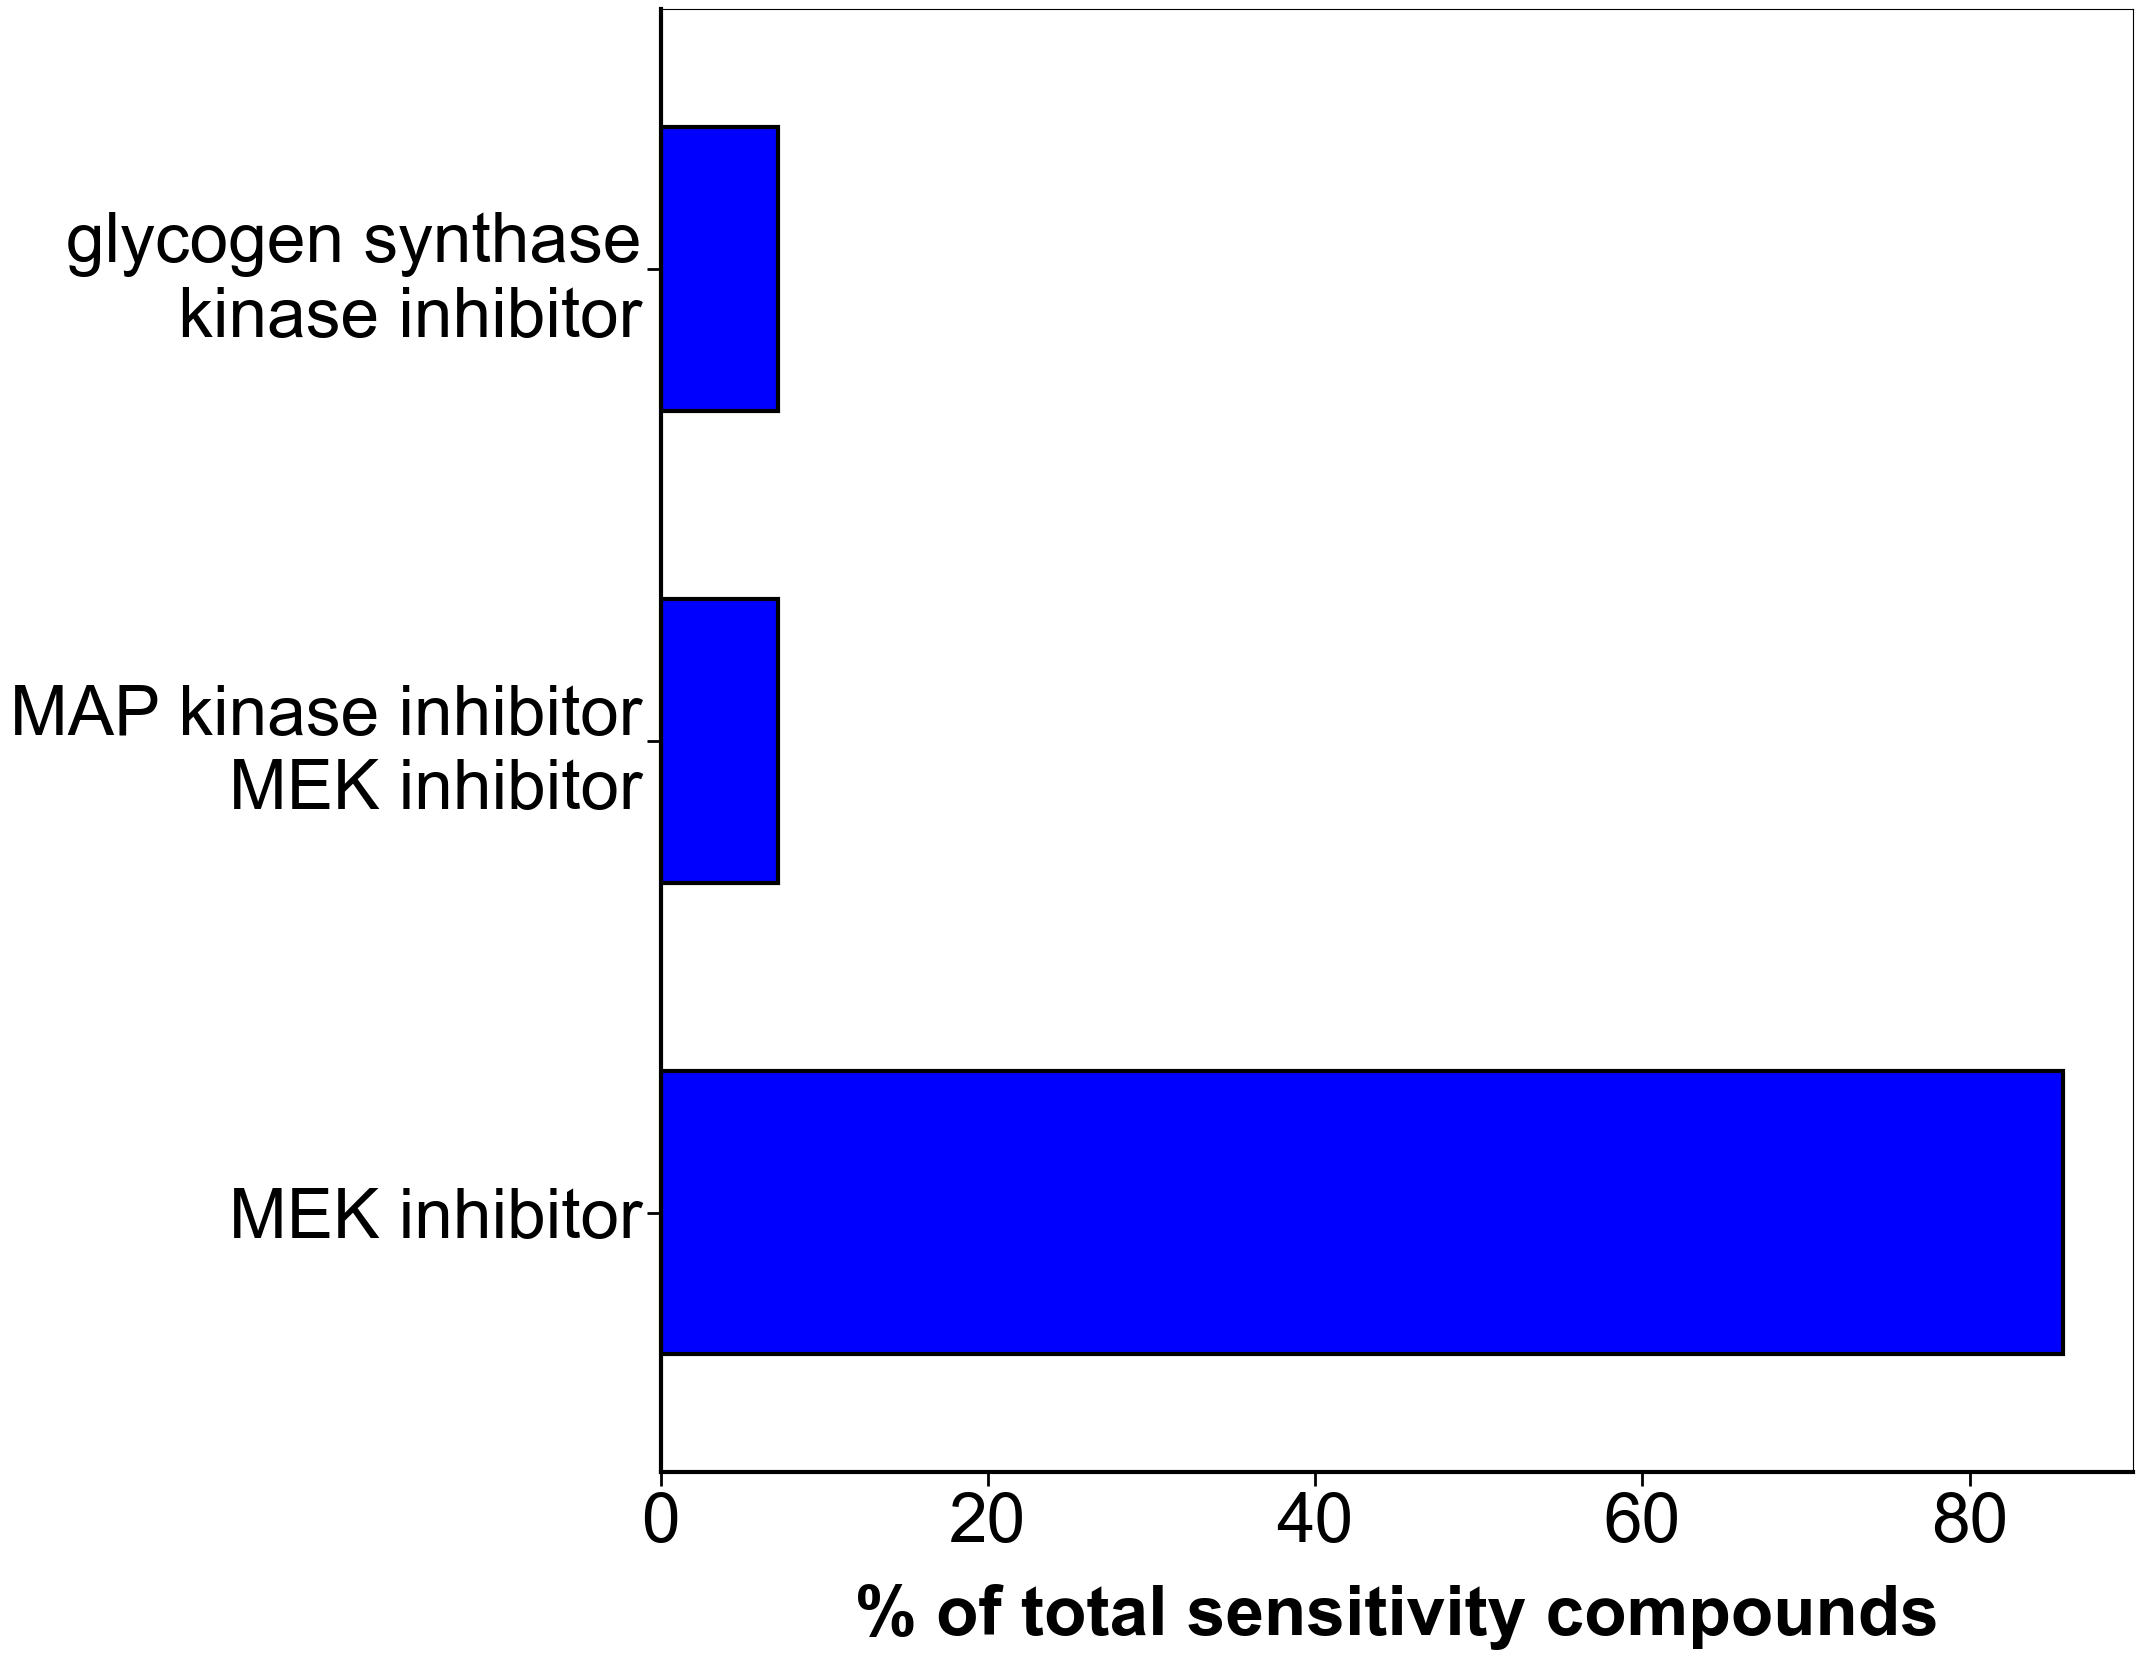

In [51]:
# Set global font to Arial
plt.rcParams['font.sans-serif'] = 'Arial'

# Colors for the bar plot
colors = ['blue']

# Create a horizontal bar plot
plotphbarsensitive = MOA_fraction.plot.barh(
    fontsize=50, 
    width=0.6, 
    figsize=(19, 19), 
    color=colors, 
    edgecolor="black",
    linewidth=3)

# Set x-axis label with larger font size and thicker font weight
plotphbarsensitive.set_xlabel('% of total sensitivity compounds', fontsize=50, fontweight='bold', labelpad=20)

# Remove y-axis label (set it to empty string)
plotphbarsensitive.set_ylabel('', fontsize=30, fontweight='bold')

# Remove legend if it exists
if plotphbarsensitive.get_legend() is not None:
    plotphbarsensitive.get_legend().remove()

# Rotate x-tick labels to 0 degrees and make x-tick numbers bold and larger
for tick in plotphbarsensitive.get_xticklabels():
    tick.set_rotation(0)  # Set rotation of x-tick labels
    tick.set_fontweight('normal')  # Make the x-axis numbers bold
    tick.set_fontsize(60)  # Make the x-axis numbers larger

# Make y-axis tick names bold and larger
for tick in plotphbarsensitive.get_yticklabels():
    tick.set_fontweight('normal')  # Make y-tick labels bold
    tick.set_fontsize(60)  # Make the y-tick labels larger

# Make axes and axis labels thicker
ax = plt.gca()
ax.tick_params(axis='y', labelsize=50)  # Increase font size of y-tick labels
ax.spines['left'].set_linewidth(3)  # Thicker left axis
ax.spines['bottom'].set_linewidth(3)  # Thicker bottom axis

# Increase tick size and line width for both axes
ax.tick_params(axis='x', labelsize=50, width=2, length=10)  # Increase width, length, and label size of x-ticks
ax.tick_params(axis='both', width=2, length=10)  # Increase width and length of ticks for both axes

# Save plot as PDF
bar_plot_pdf = "Figure1B_KRAS_sensitivity_category_bargraph.pdf"
bar_plot_tiff = "Figure1B_KRAS_sensitivity_category_bargraph.tiff"

# Save as PDF
plotpath_pdf = outputfile / bar_plot_pdf
plt.savefig(plotpath_pdf, bbox_inches='tight', format='pdf')  # Save as PDF
print(f"PDF saved at: {plotpath_pdf}")  # Optional print for confirmation

# Save as TIFF
plotpath_tiff = outputfile / bar_plot_tiff
plt.savefig(plotpath_tiff, bbox_inches='tight', format='tiff')  # Save as TIFF
print(f"TIFF saved at: {plotpath_tiff}")  # Optional print for confirmation

plt.show()
